In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
customers=pd.read_csv('messy_customer_sales_data.csv')
customers_df=customers.copy()

In [6]:
customers_df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India


In [8]:
customers_df.shape

(10200, 12)

# Column Descriptions

* **`Customer_ID`**: Unique code for each customer to identify them without errors.
* **`Name`**: Customer's full name.
* **`Gender`**: Gender category used for customer demographic analysis.
* **`Age`**: Age in years, used to group customers by age range.
* **`City`**: City where the customer lives.
* **`Signup_Date`**: Date the customer registered their account.
* **`Last_Purchase_Date`**: Date of the most recent purchase, used to spot inactive or active users.
* **`Purchase_Amount`**: Total money spent, used to track total revenue and customer spending habits.
* **`Feedback_Score`**: Rating given by the customer  to track satisfaction.
* **`Email`**: Customer's email address for communication and account checks.
* **`Phone_Number`**: Customer's phone number for contact and verification.
* **`Country`**: Country where the customer is located.

## Data Quality Report

## 1. Completeness Issues
(Information is missing.)

- `Customer_ID` contains missing values.
- `Age` contains missing values.
- `Gender` contains missing values.
- `City` contains missing values.
- `Last_Purchase_Date` contains missing values.
- `Purchase_Amount` contains missing values.
- `Feedback_Score` contains missing values.
- `Country` contains missing values.

---

## 2. Validity Issues
(Data does not follow the expected format or business rules.)

- The `Age` column contains values such as **"25 years"** instead of numeric values.
- `Purchase_Amount` contains negative values, which are invalid.
- `Age`, `Signup_Date`, and `Last_Purchase_Date` have incorrect data types and need conversion.

---

## 3. Accuracy Issues
(Data values are incorrect or unrealistic.)

- `Purchase_Amount` contains extreme outliers that may represent incorrect or suspicious entries.,
- `Age` contains outlier

---

## 4. Consistency Issues
(The same information is represented in different ways.)

- The `Gender` column contains inconsistent values such as **Male**, **male**, **M**, **Female**, **female**, and **F**.
- The `City` column contains inconsistent capitalization (e.g., **Dehli**, **dehli**, ** dehli **).
- The `Country` column contains inconsistent capitalization (e.g., **India**, **india**, **IND**).

---

## 5. Uniqueness Issues
(Data that should be unique appears multiple times.)

- The dataset contains **15 duplicate rows**.
- The `Customer_ID` column contains duplicate values.




In [9]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [10]:
customers_df.describe()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9.179000e+03,9177.000000,1.020000e+04
mean,2.909013e+04,5.479351,4.979974e+09
std,2.086971e+05,2.867123,2.902593e+09
min,-5.000000e+02,1.000000,9.208990e+05
25%,1.229500e+04,3.000000,2.449157e+09
50%,2.433000e+04,5.000000,4.988639e+09
75%,3.713000e+04,8.000000,7.510448e+09
max,9.999999e+06,10.000000,9.994402e+09


In [11]:
customers_df.isnull().sum()

Customer_ID           1023
Name                     0
Gender                1026
Age                    951
City                  1016
Signup_Date              0
Last_Purchase_Date    1012
Purchase_Amount       1021
Feedback_Score        1023
Email                    0
Phone_Number             0
Country                732
dtype: int64

In [12]:
customers_df.duplicated().sum()

np.int64(15)

In [13]:
customers_df['Customer_ID'].value_counts()

Customer_ID
CUST3344     2
CUST4893     2
CUST7000     2
CUST10824    2
CUST2695     2
            ..
CUST7857     1
CUST3881     1
CUST1565     1
CUST9038     1
CUST5957     1
Name: count, Length: 9000, dtype: int64

### Handling Missing Data

In [15]:
customers_df.dropna(subset=['Customer_ID'],inplace=True)
customers_df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                   859
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

dropped missing Customer_ID rows because it is primary key

In [85]:
customers_df['Age']

0        52.0
1        51.0
2        62.0
3        40.0
4        41.0
         ... 
10194    40.0
10195    35.0
10197    25.0
10198    55.0
10199    34.0
Name: Age, Length: 9177, dtype: float64

In [92]:
customers_df['Age'] = customers['Age'].str.split(' ').str[0]


In [95]:
df_age=customers_df['Age']

In [103]:
age_median = pd.to_numeric(df_age, errors='coerce').dropna().median()
age_median

np.float64(43.0)

In [120]:
customers_df['Age'].fillna(age_median,inplace=True)

C:\Users\ALI PC\AppData\Local\Temp\ipykernel_15104\837717716.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers_df['Age'].fillna(age_median,inplace=True)


In [122]:
customers_df['Age'] = pd.to_numeric(customers_df['Age'], errors='coerce')

In [123]:
customers_df['Age'] = customers_df['Age'].abs()

In [121]:
customers_df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

The median was chosen over the mean to fill missing age values because it is robust to extreme outliers. Since age distributions are often skewed, the median provides a more accurate representation of the typical value without shifting the data.

In [ ]:
customers_df['Purchase_Amount'].fillna(customers_df['Purchase_Amount'].median(),inplace=True)

In [62]:
customers_df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                    57
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

 Filled missing Purchase Amount with median to avoid distortion from high-value purchase outliers.

In [ ]:
customers_df['Feedback_Score'].fillna(customers_df['Feedback_Score'].mode()[0],inplace=True)

In [64]:
customers_df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                    57
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country               664
dtype: int64

Feedback scores represent discrete ratings. The mode fills missing entries with the most common, real score without introducing invalid decimal values or breaking on text categories.

In [65]:
for col in ['Gender','City','Country']:
    customers_df[col].fillna(customers_df[col].mode()[0],inplace=True)

C:\Users\ALI PC\AppData\Local\Temp\ipykernel_15104\3877472791.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers_df[col].fillna(customers_df[col].mode()[0],inplace=True)


In [66]:
customers_df.isnull().sum()

Customer_ID             0
Name                    0
Gender                  0
Age                    57
City                    0
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country                 0
dtype: int64

Filled missing categorical data with mode (most frequent value) since mean/median cannot be calculated on text.

In [67]:
customers_df['Last_Purchase_Date'].ffill(inplace=True)

C:\Users\ALI PC\AppData\Local\Temp\ipykernel_15104\1479320192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers_df['Last_Purchase_Date'].ffill(inplace=True)


In [124]:
customers_df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

 Used forward fill (ffill) to propagate the most recent purchase date down to missing entries in time-ordered data.

### Fixing Consistency Issues

In [125]:
customers_df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [126]:
customers_df['Gender']=customers_df['Gender'].str.lower().str.strip()

In [127]:
customers_df['Gender'].replace({'m':'male','f':'female'},inplace=True)

C:\Users\ALI PC\AppData\Local\Temp\ipykernel_15104\1857676284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers_df['Gender'].replace({'m':'male','f':'female'},inplace=True)


In [128]:
customers_df['Gender'].unique()

array(['male', 'female'], dtype=object)

In [129]:
customers_df['City']=customers_df['City'].str.lower().str.strip()

In [130]:
customers_df['Country'].unique()

array(['India', 'india', 'InDia', 'IND'], dtype=object)

In [132]:
customers_df['Country']=customers_df['Country'].str.lower()

In [135]:
customers_df['Country'] = customers_df['Country'].replace('IND', 'india')

### Duplicate removal

In [136]:
customers_df.shape

(9177, 12)

In [137]:
customers_df.duplicated().sum()

np.int64(139)

In [139]:
customers_df.drop_duplicates(inplace=True)
customers_df.shape

(9038, 12)

#### Removed 139 duplicated entries

In [140]:
customers_df['Customer_ID'].value_counts()

Customer_ID
CUST4196     2
CUST9950     2
CUST10702    2
CUST5320     2
CUST5472     2
            ..
CUST7857     1
CUST3881     1
CUST1565     1
CUST9038     1
CUST5957     1
Name: count, Length: 9000, dtype: int64

In [141]:
# removing duplicated customer_id
customers_df.drop_duplicates(subset=['Customer_ID'],keep='first' ,inplace=True)

In [142]:
customers_df['Customer_ID'].value_counts()

Customer_ID
CUST4812    1
CUST4371    1
CUST5957    1
CUST3754    1
CUST2934    1
           ..
CUST1303    1
CUST8028    1
CUST3260    1
CUST8237    1
CUST5189    1
Name: count, Length: 9000, dtype: int64

### Data type correction

In [143]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9000 non-null   object 
 1   Name                9000 non-null   object 
 2   Gender              9000 non-null   object 
 3   Age                 9000 non-null   float64
 4   City                9000 non-null   object 
 5   Signup_Date         9000 non-null   object 
 6   Last_Purchase_Date  9000 non-null   object 
 7   Purchase_Amount     9000 non-null   float64
 8   Feedback_Score      9000 non-null   float64
 9   Email               9000 non-null   object 
 10  Phone_Number        9000 non-null   int64  
 11  Country             9000 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 914.1+ KB


In [146]:
customers_df['Signup_Date']=pd.to_datetime(customers_df['Signup_Date'])
customers_df['Last_Purchase_Date']=pd.to_datetime(customers_df['Last_Purchase_Date'])
customers_df['Feedback_Score']=customers_df['Feedback_Score'].astype('int32')

In [147]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         9000 non-null   object        
 1   Name                9000 non-null   object        
 2   Gender              9000 non-null   object        
 3   Age                 9000 non-null   float64       
 4   City                9000 non-null   object        
 5   Signup_Date         9000 non-null   datetime64[ns]
 6   Last_Purchase_Date  9000 non-null   datetime64[ns]
 7   Purchase_Amount     9000 non-null   float64       
 8   Feedback_Score      9000 non-null   int32         
 9   Email               9000 non-null   object        
 10  Phone_Number        9000 non-null   int64         
 11  Country             9000 non-null   object        
dtypes: datetime64[ns](2), float64(2), int32(1), int64(1), object(6)
memory usage: 878.9+ KB


### Handling Outliers
Using z-score

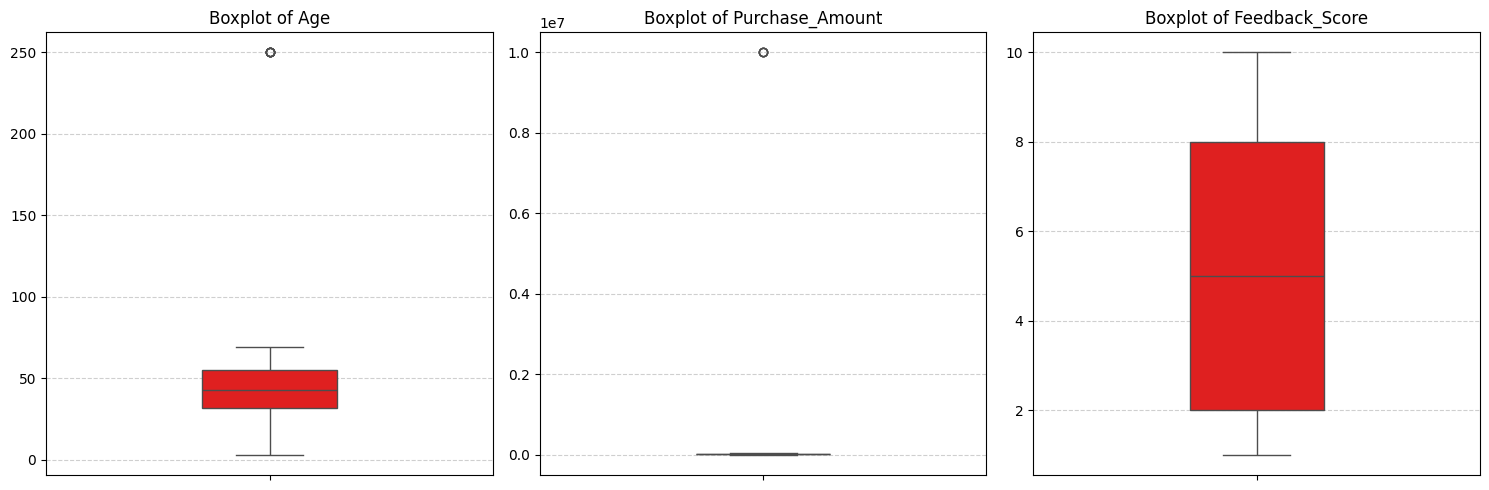

In [148]:
cols=['Age','Purchase_Amount','Feedback_Score']
plt.figure(figsize=(15,5))

for i,col in enumerate(cols,1):
    plt.subplot(1,3,i)
    sns.boxplot(y=customers_df[col],color='red',width=0.3)
    plt.title(f'Boxplot of {col}',fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y',linestyle='--',alpha=0.6)

plt.tight_layout()
plt.show()

In [149]:
from scipy import stats
z_scores=np.abs(stats.zscore(customers_df[['Age','Purchase_Amount']]))

In [150]:
cleaned_customers_data=customers_df[~(z_scores>3).any(axis=1)]

In [151]:
cleaned_customers_data.shape

(8989, 12)

Removed extreme outliers with |Z-score| > 3 to prevent distorted feature distributions and model bias.

In [153]:
import pandas as pd

def print_cleaning_summary(df, stage=""):
    print(f"=== {stage} CLEANING SUMMARY ===")
    print(f"Total Rows:       {len(df)}")
    print(f"Total Duplicates: {df.duplicated().sum()}")
    print(f"Total Nulls:      {df.isnull().sum().sum()}")
    print("\nData Types:")
    print(df.dtypes)
    print("=" * 30 + "\n")


In [154]:
print_cleaning_summary(customers,'Before')

=== Before CLEANING SUMMARY ===
Total Rows:       10200
Total Duplicates: 15
Total Nulls:      7804

Data Types:
Customer_ID            object
Name                   object
Gender                 object
Age                    object
City                   object
Signup_Date            object
Last_Purchase_Date     object
Purchase_Amount       float64
Feedback_Score        float64
Email                  object
Phone_Number            int64
Country                object
dtype: object



In [155]:
print_cleaning_summary(cleaned_customers_data,'After')

=== After CLEANING SUMMARY ===
Total Rows:       8989
Total Duplicates: 0
Total Nulls:      0

Data Types:
Customer_ID                   object
Name                          object
Gender                        object
Age                          float64
City                          object
Signup_Date           datetime64[ns]
Last_Purchase_Date    datetime64[ns]
Purchase_Amount              float64
Feedback_Score                 int32
Email                         object
Phone_Number                   int64
Country                       object
dtype: object



In [157]:
cleaned_customers_data.to_csv('cleaned_customers.csv', index=False)